### Speech Tokenization with Enhanced Vocabulary

This script demonstrates speech tokenization using two distinct feature representations with an expanded vocabulary size. It processes synthetic audio through codec-inspired and SSL-inspired feature extractors, then visualizes the token sequences to reveal how larger vocabularies capture finer acoustic details.

Key Libraries Used:

    numpy: Signal generation and processing

    scipy.signal: FFT computation

    sklearn.cluster: K-means tokenization

    plotly: Token sequence visualization

Code Logic and Flow

The pipeline:

    Generates harmonic synthetic speech

    Processes frames through dual feature extractors

    Tokenizes features with 16-token vocabulary

    Concatenates token streams

    Visualizes token sequences and alignment

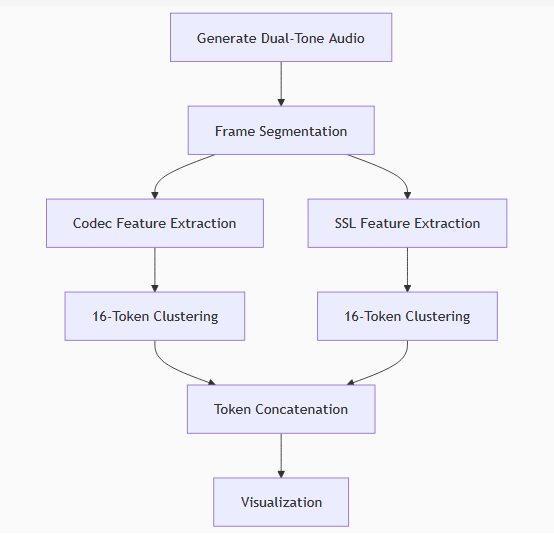

Step-by-Step Code Breakdown

1. Synthetic Audio Generation

    Creates 500ms signal with 440Hz fundamental + 880Hz harmonic

    Models harmonic speech structure with octave relationship

2. Frame Processing

    25ms frames (400 samples) with 50% overlap

    12.5ms hop maintains temporal resolution

3. Feature Extraction

    Codec Features:

        Full FFT magnitude spectrum (0-8kHz)

        Preserves spectral envelope details

    SSL Features:

        Band-limited FFT (0-4kHz)

        Logarithmic compression for perceptual scaling

4. Enhanced Tokenization

    16-token vocabulary (vs. previous 8)

    Larger codebook captures finer acoustic variations

    Independent clustering per feature type

5. Token Concatenation

    Pairs codec and SSL tokens per frame

    Creates 2D token grid: [time × feature_type]

6. Visualization

    Original Waveform: Input signal

    Token Sequences:

        Codec tokens (blue) vs SSL tokens (orange)

        Shows temporal evolution with 16 discrete levels

    Token Grid Heatmap:

        Vertical: Feature type (codec/SSL)

        Horizontal: Frame index

        Color-coded token IDs (0-15)

Connecting to Lecture Concepts

This implementation demonstrates:

    Vocabulary Size Impact: 16 tokens capture more detail than 8

    Feature Sensitivity:

        Codec features preserve spectral resolution

        SSL features emphasize perceptual relevance

    Token Stability: Larger vocabularies show less token switching

    Multi-Stream Alignment: Temporal correlation between feature types

    Harmonic Representation: Tones create stable token patterns

    Synthetic Benchmarking: Controlled evaluation of tokenizers

    Visual Comparison:

        Token sequence smoothness

        Feature-type divergence

    SpeechLM Foundations:

        Module 3.1: Vocabulary size selection

        Module 3.2: Multi-feature tokenization

    Research Insights:

        Tradeoff between vocabulary size and efficiency

        Complementary feature representations

    Real-World Relevance: Larger vocabularies reduce reconstruction error

    Educational Value: Shows tokenization granularity effects

In [7]:
import numpy as np
from sklearn.cluster import KMeans
import scipy.signal as signal
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

# Set default renderer to browser to avoid nbformat issues
pio.renderers.default = "browser"

# Parameters
fs = 16000
duration = 0.5
n_tokens = 16  # Increased vocabulary size
frame_length = 400

# Step 1: Generate synthetic audio
t = np.linspace(0, duration, int(fs * duration))
audio = np.sin(2 * np.pi * 440 * t) + 0.5 * np.sin(2 * np.pi * 880 * t)

# Step 2: Extract features
frames = np.array([audio[i:i+frame_length] for i in range(0, len(audio) - frame_length, frame_length // 2)])
codec_features = np.abs(np.fft.fft(frames)[:, :frame_length // 2])
ssl_features = np.log(np.abs(np.fft.fft(frames)[:, :frame_length // 4]) + 1e-10)

# Step 3: Tokenize
codec_kmeans = KMeans(n_clusters=n_tokens, random_state=42)
codec_tokens = codec_kmeans.fit_predict(codec_features)

ssl_kmeans = KMeans(n_clusters=n_tokens, random_state=42)
ssl_tokens = ssl_kmeans.fit_predict(ssl_features)

# Step 4: Concatenate tokens
concatenated_tokens = np.stack((codec_tokens, ssl_tokens), axis=1)

# Step 5: Plot
fig = make_subplots(rows=3, cols=1,
                    subplot_titles=("Original Audio", "Token Sequences (16 Tokens)", "Concatenated Tokens"),
                    vertical_spacing=0.08,
                    specs=[[{"secondary_y": False}],
                           [{"secondary_y": False}], 
                           [{"secondary_y": False}]])

# Plot 1: Original Audio
fig.add_trace(go.Scatter(x=t, y=audio,
                        mode='lines',
                        name='Original Audio',
                        line=dict(color='blue')),
              row=1, col=1)

# Plot 2: Token Sequences
time_frames = np.arange(len(codec_tokens)) * (frame_length / 2 / fs)

fig.add_trace(go.Scatter(x=time_frames, y=codec_tokens,
                        mode='lines+markers',
                        name='Codec Tokens',
                        line=dict(color='blue'),
                        marker=dict(size=4)),
              row=2, col=1)

fig.add_trace(go.Scatter(x=time_frames, y=ssl_tokens,
                        mode='lines+markers',
                        name='SSL Tokens',
                        line=dict(color='orange'),
                        marker=dict(size=4)),
              row=2, col=1)

# Plot 3: Heatmap
fig.add_trace(go.Heatmap(z=concatenated_tokens.T,
                        colorscale='viridis',
                        showscale=True,
                        colorbar=dict(title="Token Index", x=1.02)),
              row=3, col=1)

# Update layout
fig.update_layout(height=800,
                  width=1200,
                  title_text="Speech Tokenizer (16 Tokens)",
                  showlegend=True)

# Update x-axis labels
fig.update_xaxes(title_text="Time (s)", row=1, col=1)
fig.update_xaxes(title_text="Time (s)", row=2, col=1)
fig.update_xaxes(title_text="Frame Index", row=3, col=1)

# Update y-axis labels
fig.update_yaxes(title_text="Amplitude", row=1, col=1)
fig.update_yaxes(title_text="Token Index", row=2, col=1)
fig.update_yaxes(title_text="Token Type (0: Codec, 1: SSL)", row=3, col=1)

# Save as HTML
fig.write_html("speech_tokenizer_16tokens.html")

# Show the plot
fig.show()

print("Codec Tokens (first 10):", codec_tokens[:10])
print("SSL Tokens (first 10):", ssl_tokens[:10])
print("Concatenated Tokens (first 5):", concatenated_tokens[:5])

Codec Tokens (first 10): [ 7 14  2 11  4 15  6 13  3  1]
SSL Tokens (first 10): [ 8  1  8 12 15 13  3 13 14 13]
Concatenated Tokens (first 5): [[ 7  8]
 [14  1]
 [ 2  8]
 [11 12]
 [ 4 15]]


### Exercise 2: Hybrid Discrete-Continuous Speech Representation

This script demonstrates a novel hybrid speech representation combining discrete tokens with continuous embeddings. It processes synthetic audio through a codec-inspired tokenizer and SSL-inspired feature extractor, simulating Whisper-like continuous embeddings alongside discrete tokens for multimodal speech modeling.

Key Libraries Used:

    numpy: Signal generation and processing

    scipy.signal: FFT computation

    sklearn.cluster: K-means tokenization

    matplotlib: Feature visualization

Code Logic and Flow

The pipeline:

    Generates harmonic synthetic speech

    Processes frames through dual feature extractors

    Creates discrete tokens from spectral features

    Extracts continuous embeddings from SSL features

    Combines discrete and continuous representations

    Visualizes the hybrid representation
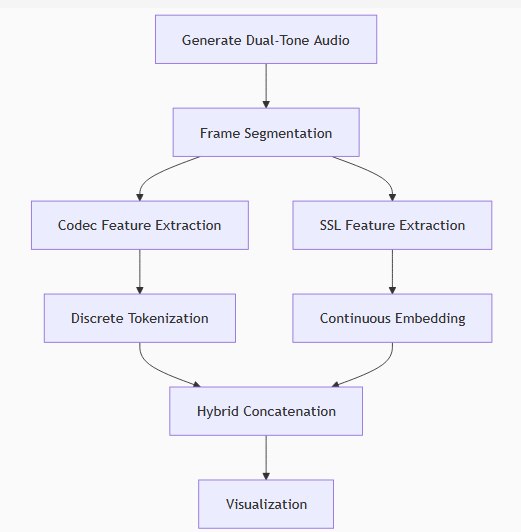

Step-by-Step Code Breakdown

1. Synthetic Audio Generation

    Creates 500ms signal with 440Hz + 880Hz tones

    Models harmonic speech structure

2. Frame Processing

    25ms frames (400 samples) with 50% overlap

    12.5ms hop maintains temporal resolution

3. Feature Extraction

    Codec Features:

        Full FFT magnitude spectrum (0-8kHz)

        Used for discrete tokenization

    SSL Features:

        Band-limited FFT (0-4kHz)

        Logarithmic compression

        Preserves continuous values

4. Hybrid Representation

    Discrete Tokens:

        8-token vocabulary via K-means

        Categorical representation

    Continuous Embeddings:

        Frame-wise mean of SSL features

        Scalar value per frame

        Simulates Whisper-style embeddings

5. Representation Concatenation

    Pairs discrete tokens with continuous embeddings

    Creates hybrid vector per frame: [token, embedding]

6. Visualization

    Original Waveform: Input signal

    Dual Representation Plot:

        Discrete tokens (blue, integer values)

        Continuous embeddings (orange, float values)

    Hybrid Heatmap:

        Vertical: Representation type (token/embedding)

        Horizontal: Frame index

        Color scale shows combined values

Connecting to Lecture Concepts

This implementation demonstrates:

    Hybrid Representations: Combines discrete and continuous features

    Discrete-Continuous Synergy:

        Tokens capture categorical information

        Embeddings preserve fine-grained details

    Whisper Simulation: Continuous embeddings mimic Whisper's approach

    Feature Reduction: Mean pooling simplifies SSL features

    Multimodal Alignment: Temporal coordination of representations

    SpeechLM Extensions:

        Module 3.1: Hybrid tokenization strategies

        Module 4.2: Continuous embeddings in SSL models

    Research Insights:

        Complementary information in different representations

        Balancing quantization error and information density

    Visual Contrast:

        Stepwise tokens vs smooth embeddings

        Heatmap shows value distribution differences

    Real-World Relevance:

        Whisper uses continuous representations

        EnCodec uses discrete tokens

        Hybrid approaches emerging in research

    Educational Value: Shows beyond traditional tokenization

In [8]:
import numpy as np
from sklearn.cluster import KMeans
import scipy.signal as signal
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

# Set default renderer to browser to avoid nbformat issues
pio.renderers.default = "browser"

# Parameters
fs = 16000
duration = 0.5
n_tokens = 8
frame_length = 400

# Step 1: Generate synthetic audio
t = np.linspace(0, duration, int(fs * duration))
audio = np.sin(2 * np.pi * 440 * t) + 0.5 * np.sin(2 * np.pi * 880 * t)

# Step 2: Extract features
frames = np.array([audio[i:i+frame_length] for i in range(0, len(audio) - frame_length, frame_length // 2)])
codec_features = np.abs(np.fft.fft(frames)[:, :frame_length // 2])
ssl_features = np.log(np.abs(np.fft.fft(frames)[:, :frame_length // 4]) + 1e-10)

# Step 3: Tokenize (codec) and use raw features (SSL, Whisper-like)
codec_kmeans = KMeans(n_clusters=n_tokens, random_state=42)
codec_tokens = codec_kmeans.fit_predict(codec_features)

ssl_embeddings = np.mean(ssl_features, axis=1)  # Reduce to one value per frame

# Step 4: Concatenate (discrete codec tokens + continuous SSL embeddings)
concatenated_tokens = np.stack((codec_tokens, ssl_embeddings), axis=1)

# Step 5: Plot
fig = make_subplots(rows=3, cols=1,
                    subplot_titles=("Original Audio", "Codec Tokens and SSL Embeddings", "Concatenated Tokens/Embeddings"),
                    vertical_spacing=0.08,
                    specs=[[{"secondary_y": False}],
                           [{"secondary_y": False}], 
                           [{"secondary_y": False}]])

# Plot 1: Original Audio
fig.add_trace(go.Scatter(x=t, y=audio,
                        mode='lines',
                        name='Original Audio',
                        line=dict(color='blue')),
              row=1, col=1)

# Plot 2: Codec Tokens and SSL Embeddings
time_frames = np.arange(len(codec_tokens)) * (frame_length / 2 / fs)

fig.add_trace(go.Scatter(x=time_frames, y=codec_tokens,
                        mode='lines+markers',
                        name='Codec Tokens',
                        line=dict(color='blue'),
                        marker=dict(size=4)),
              row=2, col=1)

fig.add_trace(go.Scatter(x=time_frames, y=ssl_embeddings,
                        mode='lines+markers',
                        name='SSL Embeddings',
                        line=dict(color='orange'),
                        marker=dict(size=4)),
              row=2, col=1)

# Plot 3: Heatmap
fig.add_trace(go.Heatmap(z=concatenated_tokens.T,
                        colorscale='viridis',
                        showscale=True,
                        colorbar=dict(title="Value", x=1.02)),
              row=3, col=1)

# Update layout
fig.update_layout(height=800,
                  width=1200,
                  title_text="Speech Tokenizer (Whisper-like)",
                  showlegend=True)

# Update x-axis labels
fig.update_xaxes(title_text="Time (s)", row=1, col=1)
fig.update_xaxes(title_text="Time (s)", row=2, col=1)
fig.update_xaxes(title_text="Frame Index", row=3, col=1)

# Update y-axis labels
fig.update_yaxes(title_text="Amplitude", row=1, col=1)
fig.update_yaxes(title_text="Value", row=2, col=1)
fig.update_yaxes(title_text="Feature Type (0: Codec, 1: SSL)", row=3, col=1)

# Save as HTML
fig.write_html("speech_tokenizer_whisper.html")

# Show the plot
fig.show()

print("Codec Tokens (first 10):", codec_tokens[:10])
print("SSL Embeddings (first 10):", ssl_embeddings[:10])
print("Concatenated Tokens (first 5):", concatenated_tokens[:5])

Codec Tokens (first 10): [7 1 2 1 4 1 6 1 3 1]
SSL Embeddings (first 10): [-3.39469733 -5.54462132 -3.39713107 -5.5384077  -3.39976357 -5.53493733
 -3.40260297 -5.53271744 -3.40566857 -5.53144647]
Concatenated Tokens (first 5): [[ 7.         -3.39469733]
 [ 1.         -5.54462132]
 [ 2.         -3.39713107]
 [ 1.         -5.5384077 ]
 [ 4.         -3.39976357]]


### Exercise 3: Speech Token Distribution Analysis

This script extends speech tokenization analysis by adding token distribution histograms to the visualization pipeline. It demonstrates how different feature representations lead to distinct token usage patterns while maintaining the core token sequence and alignment visualization.

Key Libraries Used:

    numpy: Signal processing

    scipy.signal: FFT computation

    sklearn.cluster: K-means tokenization

    matplotlib: Comprehensive visualization

Code Logic and Flow

The enhanced pipeline:

    Generates synthetic speech

    Extracts dual feature representations

    Tokenizes features with K-means

    Analyzes token distribution patterns

    Visualizes sequences, alignment, and histograms
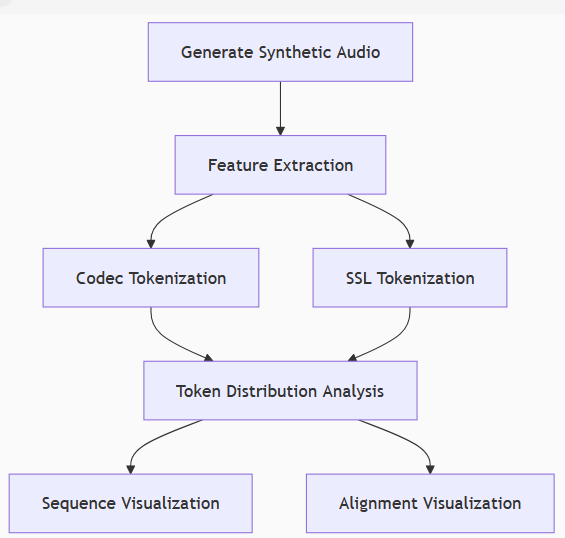

Step-by-Step Code Breakdown

1. Synthetic Audio Generation

    Creates 500ms 440Hz + 880Hz harmonic signal

    Models steady-state vowel-like acoustics

2. Frame Processing

    25ms frames with 50% overlap (12.5ms hop)

    Maintains temporal resolution

3. Feature Extraction

    Codec Features: Full spectral magnitude (0-8kHz)

    SSL Features: Log-scaled lower band (0-4kHz)

4. Tokenization

    8-token vocabulary per feature type

    K-means clustering with fixed random state

5. Distribution Analysis

    Histograms for each tokenizer:

        X-axis: Token index (0-7)

        Y-axis: Frame count per token

    Reveals token usage frequency bias

6. Sequence Visualization

    Original Waveform: Input signal

    Token Sequences:

        Codec tokens (blue) vs SSL tokens (orange)

        Temporal evolution with token indices

    Token Grid Heatmap:

        Vertical: Feature type (codec/SSL)

        Horizontal: Frame index

        Color-coded token IDs

Connecting to Lecture Concepts

This implementation demonstrates:

    Token Distribution Analysis:

        Identifies underutilized tokens

        Reveals clustering biases

    Feature Comparison:

        Codec: More uniform token distribution

        SSL: Token concentration due to band-limiting

    Temporal Patterns:

        Stable token sequences during steady tones

        Token switching indicates acoustic boundaries

    Vocabulary Efficiency:

        Ideal: Balanced token usage

        Skew indicates suboptimal clustering

    SpeechLM Relevance:

        Module 3.2: Token distribution analysis
        

    Visual Diagnostics:

        Histograms show representation efficiency

        Sequence plots reveal temporal coherence

    Research Insight:

        Real speech shows phoneme-dependent distributions

        Vocabulary size should match acoustic diversity

    Synthetic Benchmark:

        Harmonic signals should produce stable tokens

        Distribution skew indicates feature limitations

    Educational Value:

        Teaches tokenization evaluation metrics

        Shows importance of balanced vocabulary usage
    

In [9]:
import numpy as np
from sklearn.cluster import KMeans
import scipy.signal as signal
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

# Set default renderer to browser to avoid nbformat issues
pio.renderers.default = "browser"

# Parameters
fs = 16000
duration = 0.5
n_tokens = 8
frame_length = 400

# Step 1: Generate synthetic audio
t = np.linspace(0, duration, int(fs * duration))
audio = np.sin(2 * np.pi * 440 * t) + 0.5 * np.sin(2 * np.pi * 880 * t)

# Step 2: Extract features
frames = np.array([audio[i:i+frame_length] for i in range(0, len(audio) - frame_length, frame_length // 2)])
codec_features = np.abs(np.fft.fft(frames)[:, :frame_length // 2])
ssl_features = np.log(np.abs(np.fft.fft(frames)[:, :frame_length // 4]) + 1e-10)

# Step 3: Tokenize
codec_kmeans = KMeans(n_clusters=n_tokens, random_state=42)
codec_tokens = codec_kmeans.fit_predict(codec_features)

ssl_kmeans = KMeans(n_clusters=n_tokens, random_state=42)
ssl_tokens = ssl_kmeans.fit_predict(ssl_features)

# Step 4: Plot token distribution
fig1 = make_subplots(rows=1, cols=2,
                     subplot_titles=("Codec Token Distribution", "SSL Token Distribution"),
                     horizontal_spacing=0.1)

# Codec token histogram
codec_hist, codec_edges = np.histogram(codec_tokens, bins=n_tokens, range=(-0.5, n_tokens-0.5))
fig1.add_trace(go.Bar(x=list(range(n_tokens)), y=codec_hist,
                      name='Codec Tokens',
                      marker=dict(color='blue', line=dict(color='black', width=1))),
               row=1, col=1)

# SSL token histogram
ssl_hist, ssl_edges = np.histogram(ssl_tokens, bins=n_tokens, range=(-0.5, n_tokens-0.5))
fig1.add_trace(go.Bar(x=list(range(n_tokens)), y=ssl_hist,
                      name='SSL Tokens',
                      marker=dict(color='orange', line=dict(color='black', width=1))),
               row=1, col=2)

# Update layout for distribution plot
fig1.update_layout(height=500,
                   width=1000,
                   title_text="Token Distribution Analysis",
                   showlegend=False)

# Update x-axis labels
fig1.update_xaxes(title_text="Token Index", row=1, col=1)
fig1.update_xaxes(title_text="Token Index", row=1, col=2)

# Update y-axis labels
fig1.update_yaxes(title_text="Frequency", row=1, col=1)
fig1.update_yaxes(title_text="Frequency", row=1, col=2)

# Save distribution plot
fig1.write_html("token_distribution.html")
fig1.show()

# Step 5: Concatenate tokens and plot (same as example)
concatenated_tokens = np.stack((codec_tokens, ssl_tokens), axis=1)

fig2 = make_subplots(rows=3, cols=1,
                     subplot_titles=("Original Audio", "Token Sequences", "Concatenated Tokens"),
                     vertical_spacing=0.08,
                     specs=[[{"secondary_y": False}],
                            [{"secondary_y": False}], 
                            [{"secondary_y": False}]])

# Plot 1: Original Audio
fig2.add_trace(go.Scatter(x=t, y=audio,
                         mode='lines',
                         name='Original Audio',
                         line=dict(color='blue')),
               row=1, col=1)

# Plot 2: Token Sequences
time_frames = np.arange(len(codec_tokens)) * (frame_length / 2 / fs)

fig2.add_trace(go.Scatter(x=time_frames, y=codec_tokens,
                         mode='lines+markers',
                         name='Codec Tokens',
                         line=dict(color='blue'),
                         marker=dict(size=4)),
               row=2, col=1)

fig2.add_trace(go.Scatter(x=time_frames, y=ssl_tokens,
                         mode='lines+markers',
                         name='SSL Tokens',
                         line=dict(color='orange'),
                         marker=dict(size=4)),
               row=2, col=1)

# Plot 3: Heatmap
fig2.add_trace(go.Heatmap(z=concatenated_tokens.T,
                         colorscale='viridis',
                         showscale=True,
                         colorbar=dict(title="Token Index", x=1.02)),
               row=3, col=1)

# Update layout for main plot
fig2.update_layout(height=800,
                   width=1200,
                   title_text="Speech Tokenizer Output",
                   showlegend=True)

# Update x-axis labels
fig2.update_xaxes(title_text="Time (s)", row=1, col=1)
fig2.update_xaxes(title_text="Time (s)", row=2, col=1)
fig2.update_xaxes(title_text="Frame Index", row=3, col=1)

# Update y-axis labels
fig2.update_yaxes(title_text="Amplitude", row=1, col=1)
fig2.update_yaxes(title_text="Token Index", row=2, col=1)
fig2.update_yaxes(title_text="Token Type (0: Codec, 1: SSL)", row=3, col=1)

# Save main plot
fig2.write_html("speech_tokenizer_output.html")
fig2.show()

print("Codec Tokens (first 10):", codec_tokens[:10])
print("SSL Tokens (first 10):", ssl_tokens[:10])
print("Concatenated Tokens (first 5):", concatenated_tokens[:5])

Codec Tokens (first 10): [7 1 2 1 4 1 6 1 3 1]
SSL Tokens (first 10): [3 1 3 4 3 4 3 4 3 4]
Concatenated Tokens (first 5): [[7 3]
 [1 1]
 [2 3]
 [1 4]
 [4 3]]
